<a href="https://colab.research.google.com/github/capt-coffey/Data_Engineering_Final/blob/main/geo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas

In [ ]:
from pathlib import Path
import geopandas as gpd
Path("data/raw/geo").mkdir(parents=True, exist_ok=True)

In [ ]:
gdf = gpd.read_file("Neighborhoods.shp")

In [ ]:
print(len(gdf))  # should be 79

88


In [ ]:
extras = [
    "Bellefontaine/Calvary Cemetery",
    "Carondelet Park",
    "Fairground Park",
    "Forest Park",
    "Missouri Botanical Garden",
    "O'Fallon Park",
    "Penrose Park",
    "Tower Grove Park",
    "Willmore Park"
]

In [ ]:
gdf_clean = gdf[~gdf["NHD_NAME"].isin(extras)].copy()

print("rows after filter:", len(gdf_clean))
print("unique names after filter:", gdf_clean["NHD_NAME"].nunique())

rows after filter: 79
unique names after filter: 79


In [ ]:
gdf_clean = gdf_clean.to_crs("EPSG:4326")

In [ ]:
gdf_clean.to_file(
    "data/raw/geo/stl_neighborhoods.geojson",
    driver="GeoJSON"
)

In [ ]:
if len(gdf_clean) != 79:
    raise ValueError(f"Expected 79 neighborhoods, found {len(gdf_clean)}")

In [ ]:
fema_gdf = gpd.read_file("S_FLD_HAZ_AR.shp")

In [ ]:
print("rows:", len(fema_gdf))
print("columns:", fema_gdf.columns)
print("crs:", fema_gdf.crs)

rows: 261
columns: Index(['DFIRM_ID', 'VERSION_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE',
       'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM', 'DEPTH', 'LEN_UNIT',
       'VELOCITY', 'VEL_UNIT', 'AR_REVERT', 'AR_SUBTRV', 'BFE_REVERT',
       'DEP_REVERT', 'DUAL_ZONE', 'SOURCE_CIT', 'geometry'],
      dtype='object')
crs: EPSG:4269


In [ ]:
fema_gdf = fema_gdf.to_crs("EPSG:4326")

In [ ]:
fema_gdf.to_file(
    "data/raw/geo/fema_flood_zones.geojson",
    driver="GeoJSON"
)

In [ ]:
print(fema_gdf.columns)

Index(['DFIRM_ID', 'VERSION_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE',
       'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM', 'DEPTH', 'LEN_UNIT',
       'VELOCITY', 'VEL_UNIT', 'AR_REVERT', 'AR_SUBTRV', 'BFE_REVERT',
       'DEP_REVERT', 'DUAL_ZONE', 'SOURCE_CIT', 'geometry'],
      dtype='object')


In [ ]:
print("Neighborhood CRS:", gdf_clean.crs)
print("FEMA CRS:", fema_gdf.crs)

Neighborhood CRS: EPSG:4326
FEMA CRS: EPSG:4326


In [ ]:
tracts_gdf = gpd.read_file("tl_2025_29_tract.shp")

In [ ]:
print(tracts_gdf.columns)
print(len(tracts_gdf))
print(tracts_gdf.crs)

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='object')
1654
EPSG:4269


In [ ]:
tracts_gdf["COUNTYFP"].unique()

array(['063', '189', '071', '009', '165', '101', '213', '135', '510',
       '051', '187', '019', '183', '141', '037', '131', '067', '003',
       '133', '055', '047', '159', '095', '027', '077', '217', '021',
       '137', '111', '221', '209', '161', '169', '145', '045', '197',
       '149', '107', '091', '059', '153', '211', '123', '223', '065',
       '029', '075', '015', '041', '177', '125', '207', '093', '005',
       '113', '017', '175', '039', '053', '043', '025', '173', '151',
       '099', '201', '119', '079', '001', '007', '105', '157', '227',
       '163', '186', '127', '097', '085', '181', '057', '117', '129',
       '089', '109', '031', '069', '179', '081', '167', '103', '023',
       '225', '147', '083', '203', '115', '199', '195', '073', '219',
       '035', '049', '061', '171', '215', '155', '121', '229', '205',
       '033', '087', '143', '139', '013', '011', '185'], dtype=object)

In [ ]:
tracts_gdf = tracts_gdf[
    tracts_gdf["COUNTYFP"].isin(["510", "189"])
]

In [ ]:
tracts_gdf = tracts_gdf.to_crs("EPSG:4326")

In [ ]:
print("tract CRS:", tracts_gdf.crs)

tract CRS: EPSG:4326


In [ ]:
projected_crs = "EPSG:26915"

tracts_proj = tracts_gdf.to_crs(projected_crs).copy()
neighborhoods_proj = gdf_clean.to_crs(projected_crs).copy()

In [ ]:
tracts_proj["tract_area"] = tracts_proj.geometry.area

In [ ]:
overlay_gdf = gpd.overlay(tracts_proj, neighborhoods_proj, how="intersection")

In [ ]:
overlay_gdf["intersect_area"] = overlay_gdf.geometry.area
overlay_gdf["area_weight"] = overlay_gdf["intersect_area"] / overlay_gdf["tract_area"]

In [ ]:
overlay_gdf = overlay_gdf.to_crs("EPSG:4326")

In [ ]:
print("overlay rows:", len(overlay_gdf))
print(overlay_gdf.columns)

overlay_gdf[["GEOID", "NHD_NAME", "tract_area", "intersect_area", "area_weight"]].head()

overlay rows: 422
Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'tract_area', 'NHD_NUM', 'NHD_NAME', 'ANGLE', 'NHD_NUMTXT',
       'NHD_NUM_ST', 'geometry', 'intersect_area', 'area_weight'],
      dtype='object')


,GEOID,NHD_NAME,tract_area,intersect_area,area_weight
0,29189210200,Riverview,4.323576e+06,4.032177e+02,0.000093
1,29510115100,Princeton Heights,1.146029e+06,5.711141e+04,0.049834
2,29510115100,Bevo Mill,1.146029e+06,1.088546e+06,0.949842
3,29510110400,Jeff Vanderlou,8.857627e+05,7.230689e+05,0.816323
4,29510110400,Greater Ville,8.857627e+05,1.625748e+05,0.183542


In [ ]:
overlay_gdf.to_file(
    "data/raw/geo/tract_neighborhood_overlay.geojson",
    driver="GeoJSON"
)

<Axes: >

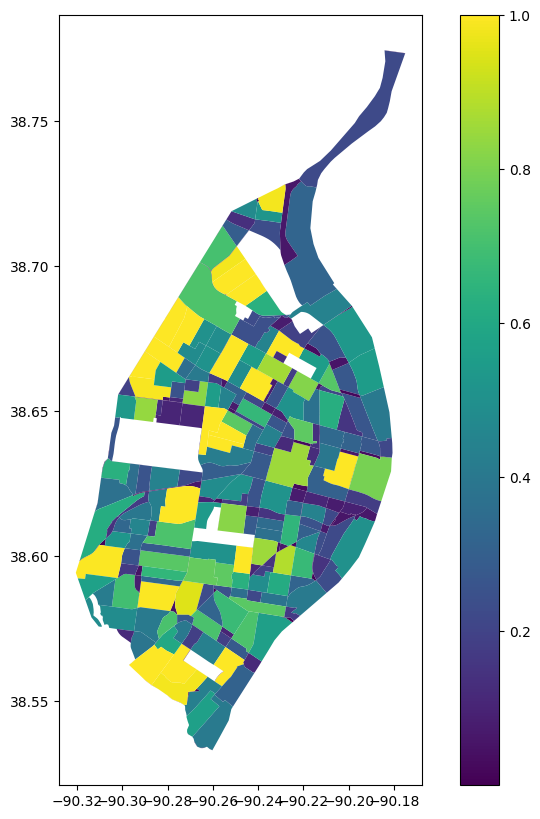

In [ ]:
overlay = gpd.read_file("data/raw/geo/tract_neighborhood_overlay.geojson")
overlay.head()
overlay.plot(
    column="area_weight",
    cmap="viridis",
    legend=True,
    figsize=(10,10)
)

In [ ]:
files.download("data/raw/geo/stl_neighborhoods.geojson")
files.download("data/raw/geo/fema_flood_zones.geojson")
files.download("data/raw/geo/tract_neighborhood_overlay.geojson")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>